In [1]:
!pip install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Filas iniciales: 224166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 15018, number of used features: 5
[LightGBM] [Info] Start training from score 25.678852
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

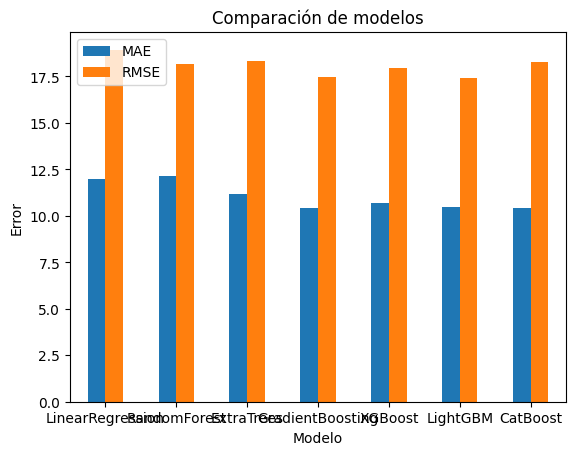

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

ARIMA
MAE: 35.8094509968904
RMSE: 45.66697557618074
             Modelo        MAE       RMSE
6          CatBoost  10.405918  18.257257
3  GradientBoosting  10.438080  17.449413
5          LightGBM  10.489204  17.440508
4           XGBoost  10.703341  17.951322
2        ExtraTrees  11.183140  18.326384
0  LinearRegression  11.979973  18.935950
1      RandomForest  12.123278  18.147685
7             ARIMA  35.809451  45.666976
Excursión 184 -> 38 personas
Excursión 546 -> 43 personas


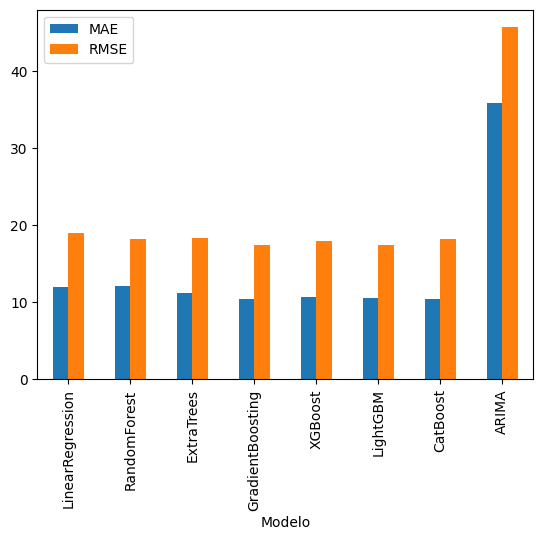

In [3]:
# ==============================
# 1. CONECTAR GOOGLE DRIVE
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 2. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


def predict_tomorrow(ev_id, model, df_final):

    tomorrow = (
        pd.Timestamp.today().normalize()
        + pd.Timedelta(days=1)
    )

    weekday = tomorrow.dayofweek
    month = tomorrow.month

    series = f"{ev_id}_{weekday}"

    serie_hist = (
        df_final[df_final['series'] == series]
        .sort_values('date')
    )

    lag_7 = serie_hist['demand'].iloc[-7]
    lag_14 = serie_hist['demand'].iloc[-14]

    X_pred = pd.DataFrame([{
        'evId': ev_id,
        'weekday': weekday,
        'month': month,
        'lag_7': lag_7,
        'lag_14': lag_14
    }])

    pred = model.predict(X_pred)

    return pred[0]



# ==============================
# 3. CARGAR DATASET
# ==============================
file_path = "/content/drive/MyDrive/ZEUS/ticket_details.csv"
df = pd.read_csv(file_path)

print("Filas iniciales:", len(df))

# ==============================
# 4. LIMPIEZA
# ==============================
df['dateFrom'] = pd.to_datetime(df['dateFrom'], errors='coerce')
df['created'] = pd.to_datetime(df['created'], errors='coerce')

df = df.dropna(subset=['dateFrom'])

# ==============================
# 5. DEMANDA
# ==============================
df['demand'] = df['adultsNum'].fillna(0) + df['childNum'].fillna(0)

# ==============================
# 6. AGRUPAR
# ==============================
df_grouped = df.groupby(['dateFrom', 'evId'], as_index=False)['demand'].sum()


max_real_date = df['dateFrom'].max()
cutoff = pd.Timestamp("2026-04-01")

df_grouped = df_grouped[df_grouped['dateFrom'] < cutoff]


#cutoff = max_real_date - pd.Timedelta(days=60)
#df_grouped = df_grouped[df_grouped['dateFrom'] < cutoff]

# ==============================
# 7. CALENDARIO
# ==============================
calendar = {
    7:   [0,1,2,3,4,5,6],
    840: [0,1,2,3,4,5,6],
    184: [0,1,2,3,4,5,6],
    546: [0,1,2,3,4,5,6],
    1920: [1,4],
    1922: [2],
    2663: [1],
    26:   [0,1,2,3,4,5],
    554:  [2,3,5],
    248:  [1,2],
    247:  [2,3,4]
}

# ==============================
# 8. GENERAR CALENDARIO
# ==============================
start = df_grouped['dateFrom'].min()
end = cutoff   # 👈 usa el corte directamente

all_dates = pd.date_range(start, end)

result = []

for ev, valid_days in calendar.items():

    valid_dates = [d for d in all_dates if d.weekday() in valid_days]

    temp = pd.DataFrame({
        'date': valid_dates,
        'evId': ev
    })

    merged = temp.merge(
        df_grouped,
        left_on=['date','evId'],
        right_on=['dateFrom','evId'],
        how='left'
    )

    merged = merged.drop(columns=['dateFrom'])
    merged['demand'] = merged['demand'].fillna(0)

    result.append(merged)

# ==============================
# 9. DATASET FINAL BASE
# ==============================
df_final = pd.concat(result)

df_final['weekday'] = df_final['date'].dt.dayofweek
df_final['month'] = df_final['date'].dt.month

df_final = df_final.sort_values(['evId','date'])

# ==============================
# 🔥 10. CREAR SERIES (MEJORA CLAVE)
# ==============================
df_final['series'] = df_final['evId'].astype(str) + "_" + df_final['weekday'].astype(str)

# ==============================
# 🔥 11. LAGS (CLAVE PARA BAJAR ERROR)
# ==============================
df_final['lag_7'] = df_final.groupby('series')['demand'].shift(7)
df_final['lag_14'] = df_final.groupby('series')['demand'].shift(14)
# ==============================
# 12. LIMPIAR NA DE LAGS
# ==============================
df_final = df_final.dropna()

# ==============================
# 13. FILTRAR SERIES DÉBILES
# ==============================
mean_demand = df_final.groupby('evId')['demand'].mean()
valid_ev = mean_demand[mean_demand >= 3].index
df_final = df_final[df_final['evId'].isin(valid_ev)]

# print(df_final.head())

X = df_final.drop(['demand','date','series'], axis=1)
y = df_final['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


models = {

    # ==============================
    # BASELINE
    # ==============================
    "LinearRegression": LinearRegression(),

    # ==============================
    # RANDOM FOREST
    # ==============================
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    # ==============================
    # EXTRA TREES
    # ==============================
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    # ==============================
    # GRADIENT BOOSTING
    # ==============================
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    # ==============================
    # XGBOOST
    # ==============================
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    # ==============================
    # LIGHTGBM
    # ==============================
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    # ==============================
    # CATBOOST
    # ==============================
    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        verbose=0,
        random_state=42
    )
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse
    })

    # ==============================
    # 12. GRÁFICO PREDICION VS REAL (PARA TFM)
    # ==============================
    # plt.figure()
    # plt.plot(y_test.values[:100], label="Real")
    # plt.plot(y_pred[:100], label="Predicción")

    # plt.title(f"Predicción vs Real {name}")
    # plt.xlabel("Observaciones")
    # plt.ylabel("Demanda")
    # plt.legend()
    # plt.show()

    # residuos = y_test.values - y_pred
    # plt.figure()
    # plt.plot(residuos)
    # plt.axhline(y=0, linestyle='--')  # línea cero

    # plt.title(f"Error por punto (Residuos) {name}")
    # plt.xlabel("Observaciones")
    # plt.ylabel("Error")
    # plt.show()


results_df = pd.DataFrame(results)
print(results_df.sort_values("MAE"))


results_df.set_index("Modelo")[["MAE","RMSE"]].plot(kind='bar')
plt.title("Comparación de modelos")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

from statsmodels.tsa.arima.model import ARIMA

# ==============================
# SERIE ARIMA
# ==============================
serie_df = (
    df_final[df_final['evId'] == 7]
    .sort_values('date')
)

serie = serie_df['demand']

# ==============================
# TRAIN / TEST
# ==============================
train_size = int(len(serie) * 0.8)

train = serie.iloc[:train_size]
test = serie.iloc[train_size:]

# ==============================
# ENTRENAR ARIMA
# ==============================
model_arima = ARIMA(train, order=(2,1,2))

model_arima_fit = model_arima.fit()

# ==============================
# PREDECIR
# ==============================
pred = model_arima_fit.forecast(steps=len(test))

# ==============================
# MÉTRICAS
# ==============================
mae_arima = mean_absolute_error(test, pred)

rmse_arima = np.sqrt(
    mean_squared_error(test, pred)
)

print("ARIMA")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)

# ==============================
# AÑADIR A RESULTADOS
# ==============================
results.append({
    "Modelo": "ARIMA",
    "MAE": mae_arima,
    "RMSE": rmse_arima
})

# ==============================
# DATAFRAME FINAL
# ==============================
results_df = pd.DataFrame(results)

print(results_df.sort_values("MAE"))

# ==============================
# GRAFICAR RESULTADOS
# ==============================
results_df.set_index("Modelo")[["MAE","RMSE"]].plot(kind='bar')

# plt.title("Comparación de modelos")
# plt.ylabel("Error")
# plt.xticks(rotation=0)

#plt.show()



best_model = models["XGBoost"]
excursiones = [184,546]

for ev_id in excursiones:

    prediction = predict_tomorrow(
        ev_id,
        best_model,
        df_final
    )

    print(
        f"Excursión {ev_id} -> "
        f"{round(prediction)} personas"
    )



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Filas iniciales: 224166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 993
[LightGBM] [Info] Number of data points in the train set: 15018, number of used features: 9
[LightGBM] [Info] Start training from score 25.678852
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

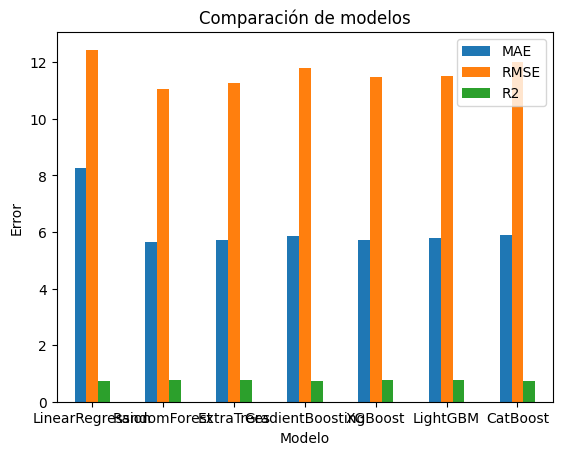

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

ARIMA
MAE: 35.8094509968904
RMSE: 45.66697557618074
             Modelo        MAE       RMSE      R2
1      RandomForest   5.637335  11.070549  0.7782
4           XGBoost   5.730482  11.477354  0.7615
2        ExtraTrees   5.731677  11.279959  0.7697
5          LightGBM   5.793327  11.518949  0.7598
3  GradientBoosting   5.854493  11.801881  0.7479
6          CatBoost   5.911568  12.024365  0.7383
0  LinearRegression   8.276300  12.443857  0.7197
7             ARIMA  35.809451  45.666976 -0.1798


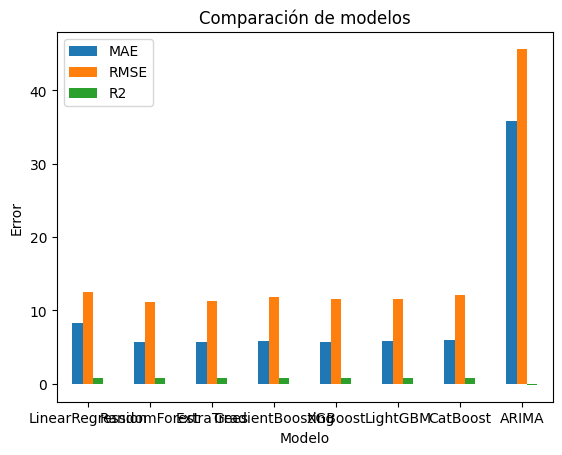

Excursión 184 -> 42 personas
Excursión 546 -> 31 personas
Excursión 7 -> 43 personas
Excursión 26 -> 29 personas


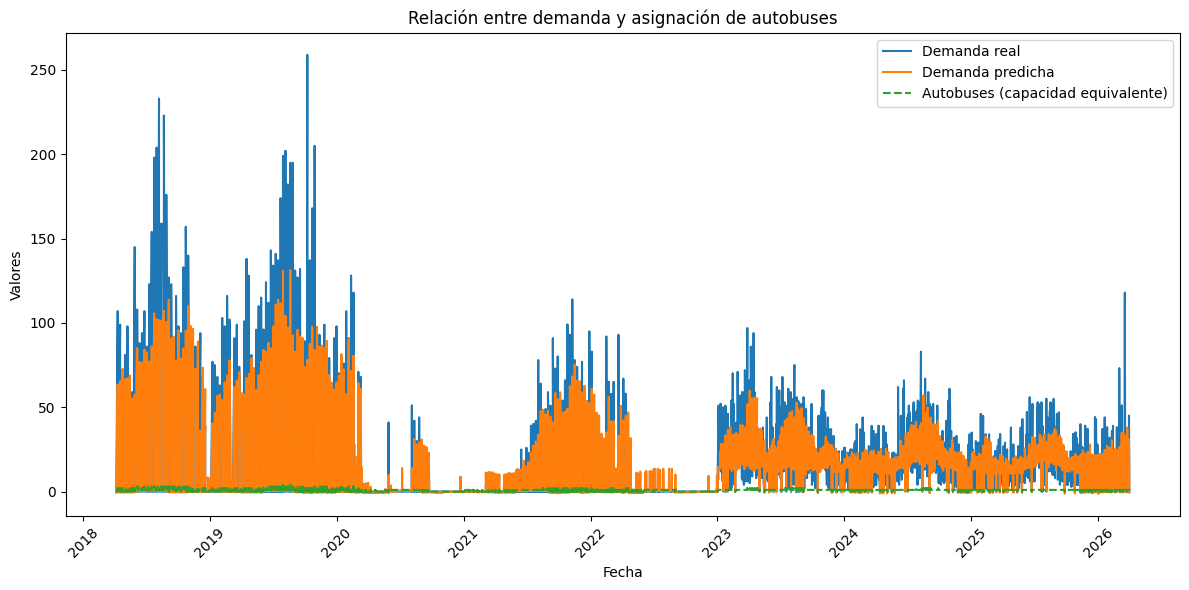

In [5]:
# ==============================
# 1. CONECTAR GOOGLE DRIVE
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 2. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def predict_tomorrow(ev_id, model, df_final):

    tomorrow = (
        pd.Timestamp.today().normalize()
        + pd.Timedelta(days=1)
    )


    weekday = tomorrow.dayofweek
    month = tomorrow.month

    series = f"{ev_id}_{weekday}"
    serie_hist = (
        df_final[df_final['series'] == series]
        .sort_values('date')
    )

    lag_1 = serie_hist['demand'].iloc[-1]
    lag_7 = serie_hist['demand'].iloc[-7]
    lag_14 = serie_hist['demand'].iloc[-14]

    rolling_4 = (
        serie_hist['demand']
        .shift(1)
        .rolling(4)
        .mean()
        .iloc[-1]
    )

    rolling_8 = (
        serie_hist['demand']
        .shift(1)
        .rolling(8)
        .mean()
        .iloc[-1]
    )


    X_pred = pd.DataFrame([{
        'evId': ev_id,
        'is_zero': 0,
        'weekday': weekday,
        'month': month,
        'lag_1':lag_1,
        'lag_7': lag_7,
        'lag_14': lag_14,
        'rolling_4': rolling_4,
        'rolling_8': rolling_8
    }])

    pred = model.predict(X_pred)

    return pred[0]



# ==============================
# 3. CARGAR DATASET
# ==============================
file_path = "/content/drive/MyDrive/ZEUS/ticket_details.csv"
df = pd.read_csv(file_path)

print("Filas iniciales:", len(df))

# ==============================
# 4. LIMPIEZA
# ==============================
df['dateFrom'] = pd.to_datetime(df['dateFrom'], errors='coerce')
df['created'] = pd.to_datetime(df['created'], errors='coerce')

df = df.dropna(subset=['dateFrom'])

# ==============================
# 5. DEMANDA
# ==============================
df['demand'] = df['adultsNum'].fillna(0) + df['childNum'].fillna(0)


# ==============================
# 6. AGRUPAR
# ==============================
df_grouped = df.groupby(['dateFrom', 'evId'], as_index=False)['demand'].sum()


max_real_date = df['dateFrom'].max()
cutoff = pd.Timestamp("2026-04-01")

df_grouped = df_grouped[df_grouped['dateFrom'] < cutoff]


#cutoff = max_real_date - pd.Timedelta(days=60)
#df_grouped = df_grouped[df_grouped['dateFrom'] < cutoff]

# ==============================
# 7. CALENDARIO
# ==============================
calendar = {
    7:   [0,1,2,3,4,5,6],
    840: [0,1,2,3,4,5,6],
    184: [0,1,2,3,4,5,6],
    546: [0,1,2,3,4,5,6],
    1920: [1,4],
    1922: [2],
    2663: [1],
    26:   [0,1,2,3,4,5],
    554:  [2,3,5],
    248:  [1,2],
    247:  [2,3,4]
}

# ==============================
# 8. GENERAR CALENDARIO
# ==============================
start = df_grouped['dateFrom'].min()
end = cutoff   # 👈 usa el corte directamente

all_dates = pd.date_range(start, end)

result = []

for ev, valid_days in calendar.items():

    valid_dates = [d for d in all_dates if d.weekday() in valid_days]

    temp = pd.DataFrame({
        'date': valid_dates,
        'evId': ev
    })

    merged = temp.merge(
        df_grouped,
        left_on=['date','evId'],
        right_on=['dateFrom','evId'],
        how='left'
    )

    merged = merged.drop(columns=['dateFrom'])
    merged['demand'] = merged['demand'].fillna(0)
    merged['is_zero'] = (merged['demand'] == 0).astype(int)

    result.append(merged)

# ==============================
# 9. DATASET FINAL BASE
# ==============================
df_final = pd.concat(result)

df_final['weekday'] = df_final['date'].dt.dayofweek
df_final['month'] = df_final['date'].dt.month

df_final = df_final.sort_values(['evId','date'])

# ==============================
# 🔥 10. CREAR SERIES (MEJORA CLAVE)
# ==============================
df_final['series'] = df_final['evId'].astype(str) + "_" + df_final['weekday'].astype(str)

# ==============================
# 🔥 11. LAGS (CLAVE PARA BAJAR ERROR)
# ==============================

df_final['lag_1'] = df_final.groupby('series')['demand'].shift(1)
df_final['lag_7'] = df_final.groupby('series')['demand'].shift(7)
df_final['lag_14'] = df_final.groupby('series')['demand'].shift(14)

df_final['rolling_4'] = (
    df_final.groupby('series')['demand']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

df_final['rolling_8'] = (
    df_final.groupby('series')['demand']
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

# ==============================
# 12. LIMPIAR NA DE LAGS
# ==============================
df_final = df_final.dropna()

# ==============================
# 13. FILTRAR SERIES DÉBILES
# ==============================
mean_demand = df_final.groupby('evId')['demand'].mean()
valid_ev = mean_demand[mean_demand >= 3].index
df_final = df_final[df_final['evId'].isin(valid_ev)]


# print(df_final.head())
X = df_final.drop(['demand','date','series'], axis=1)
y = df_final['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


models = {

    # ==============================
    # BASELINE
    # ==============================
    "LinearRegression": LinearRegression(),

    # ==============================
    # RANDOM FOREST
    # ==============================
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    # ==============================
    # EXTRA TREES
    # ==============================
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    # ==============================
    # GRADIENT BOOSTING
    # ==============================
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    # ==============================
    # XGBOOST
    # ==============================
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    # ==============================
    # LIGHTGBM
    # ==============================
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    # ==============================
    # CATBOOST
    # ==============================
    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        verbose=0,
        random_state=42
    )
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # ------------------------------
    # MAPE (corregido para ceros)
    # ------------------------------
    mape = np.mean(
        np.abs((y_test - y_pred) / (y_test + 1))
    ) * 100

    # ------------------------------
    # SMAPE (mejor que MAPE)
    # ------------------------------
    smape = 100 * np.mean(
        np.abs(y_pred - y_test) /
        ((np.abs(y_test) + np.abs(y_pred)) / 2 + 1e-8)
    )

    # ------------------------------
    # R2
    # ------------------------------
    r2 = r2_score(y_test, y_pred)

    # ------------------------------
    # MAE NORMALIZADO
    # ------------------------------
    mae_norm = mae / (y_test.mean() + 1e-8)

    # ------------------------------
    # ERROR EN PICOS (top 20%)
    # ------------------------------
    threshold = y_test.quantile(0.8)

    peak_mask = y_test > threshold

    if peak_mask.sum() > 0:
        peak_mae = mean_absolute_error(
            y_test[peak_mask],
            y_pred[peak_mask]
        )
    else:
        peak_mae = 0





    results.append({
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2":round(r2, 4)
    })

    # ==============================
    # 12. GRÁFICO PREDICION VS REAL (PARA TFM)
    # ==============================
    # plt.figure()
    # plt.plot(y_test.values[:100], label="Real")
    # plt.plot(y_pred[:100], label="Predicción")

    # plt.title(f"Predicción vs Real {name}")
    # plt.xlabel("Observaciones")
    # plt.ylabel("Demanda")
    # plt.legend()
    # plt.show()

    # residuos = y_test.values - y_pred
    # plt.figure()
    # plt.plot(residuos)
    # plt.axhline(y=0, linestyle='--')  # línea cero

    # plt.title(f"Error por punto (Residuos) {name}")
    # plt.xlabel("Observaciones")
    # plt.ylabel("Error")
    # plt.show()


results_df = pd.DataFrame(results)
print(results_df.sort_values("MAE"))


results_df.set_index("Modelo")[["MAE","RMSE","R2"]].plot(kind='bar')
plt.title("Comparación de modelos")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()



from statsmodels.tsa.arima.model import ARIMA
# ==============================
# SERIE ARIMA
# ==============================
serie_df = (
    df_final[df_final['evId'] == 7]
    .sort_values('date')
)

serie = serie_df['demand']

# ==============================
# TRAIN / TEST
# ==============================
train_size = int(len(serie) * 0.8)

train = serie.iloc[:train_size]
test = serie.iloc[train_size:]

# ==============================
# ENTRENAR ARIMA
# ==============================
model_arima = ARIMA(train, order=(2,1,2))

model_arima_fit = model_arima.fit()

# ==============================
# PREDECIR
# ==============================
pred = model_arima_fit.forecast(steps=len(test))

# ==============================
# MÉTRICAS
# ==============================
mae_arima = mean_absolute_error(test, pred)

rmse_arima = np.sqrt(
    mean_squared_error(test, pred)
)

r2 = r2_score(test, pred)

print("ARIMA")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)

# ==============================
# AÑADIR A RESULTADOS
# ==============================
results.append({
    "Modelo": "ARIMA",
    "MAE": mae_arima,
    "RMSE": rmse_arima,
    "R2":round(r2, 4)
})

# ==============================
# DATAFRAME FINAL
# ==============================
results_df = pd.DataFrame(results)

print(results_df.sort_values("MAE"))

# ==============================
# GRAFICAR RESULTADOS
# ==============================
results_df.set_index("Modelo")[["MAE","RMSE","R2"]].plot(kind='bar')

plt.title("Comparación de modelos")
plt.ylabel("Error")
plt.xticks(rotation=0)

plt.show()



best_model = models["RandomForest"]
excursiones = [184,546,7,26]

for ev_id in excursiones:

    prediction = predict_tomorrow(
        ev_id,
        best_model,
        df_final
    )

    print(
        f"Excursión {ev_id} -> "
        f"{round(prediction)} personas"
    )


# Crear DataFrame con resultados
df_plot = pd.DataFrame({
    'date': df_final.iloc[-len(y_test):]['date'].values,
    'demand_real': y_test.values,
    'demand_pred': y_pred
})

# ==============================
# CALCULAR BUSES
# ==============================
capacidad_bus = 40

df_plot['buses'] = np.ceil(df_plot['demand_pred'] / capacidad_bus)

# ==============================
# ORDENAR
# ==============================
df_plot = df_plot.sort_values('date')

# ==============================
# GRAFICAR
# ==============================
plt.figure(figsize=(12,6))

plt.plot(df_plot['date'], df_plot['demand_real'], label='Demanda real')
plt.plot(df_plot['date'], df_plot['demand_pred'], label='Demanda predicha')

# BUSES como escalones (CLAVE)
plt.step(
    df_plot['date'],
    df_plot['buses'],   # escala
    where='post',
    linestyle='--',
    label='Autobuses (capacidad equivalente)'
)


plt.title("Relación entre demanda y asignación de autobuses")
plt.xlabel("Fecha")
plt.ylabel("Valores")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



# ==============================
# 12. GUARDAR
# ==============================
#output_path = "/content/drive/MyDrive/ZEUS/dataset_forecasting.csv"
#df_final.to_csv(output_path, index=False)



Random Forest
MAE: 5.637335059800633
RMSE: 11.070549180659631


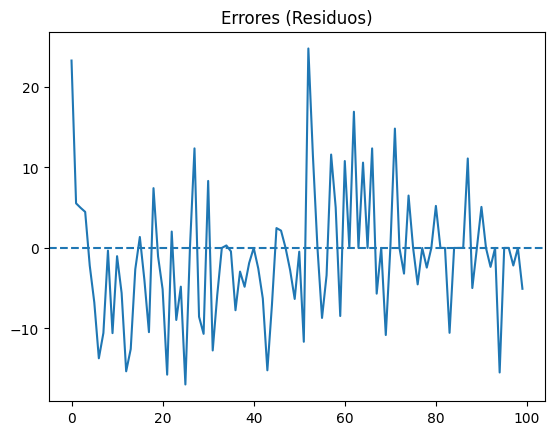

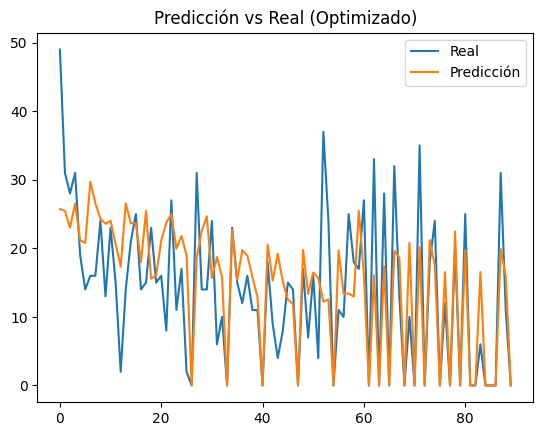

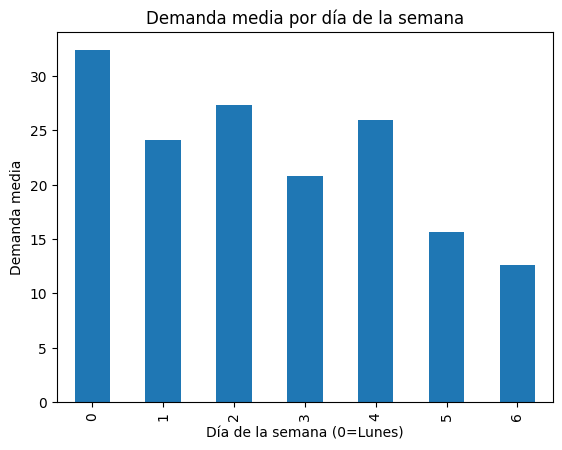

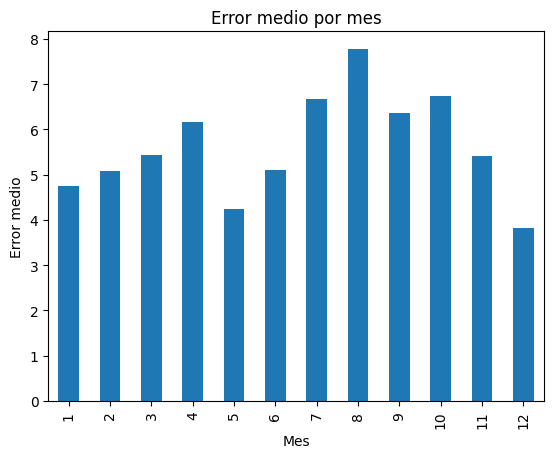

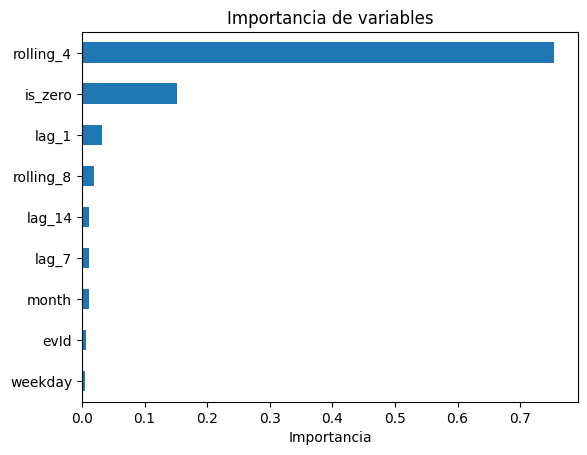

In [6]:

# ==============================
# 9. EVALUACIÓN FINAL
# ==============================
pred_opt = best_model.predict(X_test)

mae_opt = mean_absolute_error(y_test, pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, pred_opt))

print("\nRandom Forest")
print("MAE:", mae_opt)
print("RMSE:", rmse_opt)

results_df = pd.DataFrame(results)

# ==============================
# 13. RESIDUOS
# ==============================
residuos = y_test.values - pred_opt

plt.figure()
plt.plot(residuos[100:200])
plt.axhline(y=0, linestyle='--')

plt.title("Errores (Residuos)")
plt.show()



# ==============================
# 12. PREDICCIÓN VS REAL
# ==============================
plt.figure()

plt.plot(y_test.values[100:190], label="Real")
plt.plot(pred_opt[100:190], label="Predicción")

plt.title("Predicción vs Real (Optimizado)")
plt.legend()

plt.show()

demand_weekday = df_final.groupby('weekday')['demand'].mean()

plt.figure()
demand_weekday.plot(kind='bar')

plt.title("Demanda media por día de la semana")
plt.xlabel("Día de la semana (0=Lunes)")
plt.ylabel("Demanda media")

plt.show()

# ==============================
# ERROR POR PERIODO TEMPORAL
# ==============================
df_eval = pd.DataFrame({
    'date': df_final.iloc[-len(y_test):]['date'].values,
    'real': y_test.values,
    'pred': pred_opt
})

df_eval['error'] = abs(df_eval['real'] - df_eval['pred'])

# agrupar por mes
error_month = df_eval.groupby(df_eval['date'].dt.month)['error'].mean()

plt.figure()
error_month.plot(kind='bar')

plt.title("Error medio por mes")
plt.xlabel("Mes")
plt.ylabel("Error medio")

plt.show()

# ==============================
# IMPORTANCIA DE VARIABLES
# ==============================
import pandas as pd

importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importances.sort_values().tail(10).plot(kind='barh')

plt.title("Importancia de variables")
plt.xlabel("Importancia")

plt.show()
